# Q-learning Tabular di FrozenLake

**Tujuan:** memahami *Bellman equation* dan *update rule* Q-learning secara eksplisit,
tanpa neural network — sebelum melompat ke `DQN(...)` yang dipakai di `main.py`
pada repo **Stock-MARL**.

## Kaitan dengan `main.py` (Stock-MARL)

Di `main.py`, agen `ReinforcementAgent` dilatih dengan:

```python
model = DQN(
    "MlpPolicy", env,
    buffer_size=500000,
    batch_size=128,
    train_freq=(4, "step"),
    gradient_steps=1,
    target_update_interval=5000,
    exploration_fraction=0.35,
    exploration_final_eps=0.1,
    ...
)
model.learn(total_timesteps=total_timesteps, callback=callback)
```

DQN pada dasarnya adalah **Q-learning**, tetapi:

| Konsep | Q-learning tabular (notebook ini) | DQN (`main.py`) |
|---|---|---|
| Representasi nilai aksi $Q(s,a)$ | Tabel eksplisit `Q[s, a]` | Neural network (`MlpPolicy`) sebagai *function approximator* |
| Update | $Q[s,a] \mathrel{+}= \alpha (r + \gamma \max_{a'} Q[s',a'] - Q[s,a])$ dihitung langsung per langkah | Loss yang sama, tapi dioptimasi lewat *gradient descent* (`gradient_steps`) |
| Eksplorasi | $\epsilon$-greedy dengan decay manual | $\epsilon$-greedy juga, diatur oleh `exploration_fraction` & `exploration_final_eps` |
| Stabilisasi | Tidak diperlukan (tabel selalu konsisten) | Perlu *target network* (`target_update_interval`) & *replay buffer* (`buffer_size`) karena approximator neural network tidak stabil jika di-update langsung |
| State space | Diskrit & kecil (16 state di FrozenLake 4x4) | Kontinu/berdimensi tinggi (fitur pasar saham) → tabel tidak feasible |

Dengan kata lain: **Q-table di sini adalah versi "sebelum Deep" dari algoritma yang sama** yang menjadi otak `ReinforcementAgent` di simulasi pasar saham Stock-MARL. Memahami rumus update di notebook ini akan membuat parameter DQN (`target_update_interval`, `exploration_fraction`, dst.) jauh lebih masuk akal.


## 1. Setup & Import

Kita menggunakan `gymnasium` (penerus resmi `gym`) dengan environment `FrozenLake-v1`.

FrozenLake adalah grid 4x4 (default) berisi:
- `S` : posisi start
- `F` : frozen (permukaan aman, boleh dipijak)
- `H` : hole (jatuh = episode berakhir, reward 0)
- `G` : goal (episode berakhir, reward 1)

Secara default environment ini **stochastic** (`is_slippery=True`): aksi yang dipilih
tidak selalu dieksekusi persis seperti yang diminta (agen bisa "slip" ke arah lain).
Ini justru bagus untuk mendemonstrasikan mengapa Q-learning perlu berulang kali
mengunjungi tiap state-action pair sebelum estimasinya konvergen.


In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)


## 2. Teori Singkat: Bellman Equation & Q-learning

### 2.1 Markov Decision Process (MDP)

FrozenLake adalah MDP $(S, A, P, R, \gamma)$ dengan:
- $S$: himpunan state (16 posisi grid untuk peta 4x4)
- $A$: himpunan aksi (`LEFT`, `DOWN`, `RIGHT`, `UP`)
- $P(s'\mid s,a)$: probabilitas transisi (stochastic karena licin)
- $R(s,a,s')$: reward (1 jika mencapai goal, 0 lainnya)
- $\gamma$: discount factor

### 2.2 Fungsi nilai aksi $Q^{\pi}(s,a)$

$Q^{\pi}(s,a)$ = ekspektasi *return* (jumlah reward terdiskon) jika di state $s$
mengambil aksi $a$, lalu mengikuti policy $\pi$ selamanya.

### 2.3 Bellman Optimality Equation

Untuk policy optimal $\pi^*$, nilai $Q^*$ memenuhi:

$$
Q^*(s,a) = \mathbb{E}_{s' \sim P}\Big[ R(s,a,s') + \gamma \max_{a'} Q^*(s',a') \Big]
$$

Artinya: nilai optimal mengambil aksi $a$ di $s$ = reward langsung, ditambah
nilai terbaik yang bisa dicapai dari state berikutnya $s'$ (dengan aksi terbaik $a'$),
didiskon oleh $\gamma$.

### 2.4 Q-learning: Temporal-Difference update

Q-learning mengaproksimasi $Q^*$ secara *sample-based* (tanpa tahu $P$ dan $R$ secara eksplisit)
melalui update inkremental setiap kali agen mengalami transisi $(s, a, r, s')$:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ \underbrace{r + \gamma \max_{a'} Q(s',a')}_{\text{TD target}} - \underbrace{Q(s,a)}_{\text{estimasi lama}} \Big]
$$

- $\alpha$ (*learning rate*): seberapa besar kita mempercayai sample baru dibanding estimasi lama.
- Selisih di dalam kurung disebut **TD-error** — ini adalah "loss" versi Q-learning tabular.
  Pada DQN, loss yang dioptimasi neural network via gradient descent adalah versi
  *squared* dari TD-error yang sama: $\mathcal{L} = \big(r + \gamma \max_{a'} Q_{\text{target}}(s',a') - Q(s,a)\big)^2$.

Algoritma ini **off-policy**: update menggunakan $\max_{a'} Q(s',a')$ (aksi terbaik menurut
tabel saat ini), bukan aksi yang benar-benar akan diambil selanjutnya oleh policy eksplorasi.

### 2.5 Eksplorasi: $\epsilon$-greedy

Agar semua state-action pair cukup sering dikunjungi (syarat konvergensi Q-learning),
kita tidak selalu greedy terhadap tabel Q. Dengan probabilitas $\epsilon$, agen memilih
aksi acak (*explore*); selebihnya memilih $\arg\max_a Q(s,a)$ (*exploit*).

$\epsilon$ di-*decay* secara bertahap dari nilai tinggi (banyak eksplorasi di awal, saat
tabel masih kosong/tidak akurat) menuju nilai rendah (banyak eksploitasi di akhir, saat
tabel sudah cukup dipelajari). Ini konsep yang sama persis dengan `exploration_fraction`
dan `exploration_final_eps` pada `DQN(...)` di `main.py`.


## 3. Inisialisasi Environment

Kita pakai peta default 4x4 dengan `is_slippery=True` (stochastic) supaya tantangan
eksplorasi terasa nyata. Jika ingin versi deterministik yang lebih mudah dikonvergensikan
untuk debugging, set `is_slippery=False`.


In [2]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"Jumlah state : {n_states}")
print(f"Jumlah aksi  : {n_actions}  (0=LEFT, 1=DOWN, 2=RIGHT, 3=UP)")


Jumlah state : 16
Jumlah aksi  : 4  (0=LEFT, 1=DOWN, 2=RIGHT, 3=UP)


## 4. Inisialisasi Q-table

Q-table berbentuk matriks $|S| \times |A|$. Semua nilai diinisialisasi 0 —
agen belum tahu apa-apa tentang lingkungan, semua state-action pair dianggap
sama-sama tidak berharga sampai terbukti sebaliknya lewat pengalaman.


In [3]:
Q = np.zeros((n_states, n_actions))
print("Bentuk Q-table:", Q.shape)
Q


Bentuk Q-table: (16, 4)


array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## 5. Hyperparameter

- `n_episodes`: jumlah episode training (5000–10000 sesuai target task).
- `max_steps_per_episode`: batas langkah per episode agar episode yang "nyasar"
  tidak berjalan selamanya.
- `alpha`: learning rate untuk update Q.
- `gamma`: discount factor.
- `epsilon_start`, `epsilon_min`, `epsilon_decay`: parameter decay eksplorasi
  (analog `exploration_fraction` / `exploration_final_eps` pada DQN).


In [4]:
n_episodes = 8000              # antara 5000-10000 sesuai target task
max_steps_per_episode = 100

alpha = 0.1                    # learning rate
gamma = 0.99                   # discount factor

epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay = 0.0005         # decay eksponensial per episode


## 6. Pemilihan Aksi: $\epsilon$-greedy

Fungsi berikut mengimplementasikan trade-off eksplorasi-eksploitasi:
dengan probabilitas `epsilon`, pilih aksi acak; selebihnya pilih aksi dengan
nilai Q tertinggi di state saat ini.


In [5]:
def epsilon_greedy_action(Q, state, epsilon):
    """Pilih aksi dengan strategi epsilon-greedy."""
    if np.random.random() < epsilon:
        return env.action_space.sample()          # explore: aksi acak
    return int(np.argmax(Q[state, :]))             # exploit: aksi terbaik menurut Q


## 7. Training Loop

Untuk setiap episode:
1. Reset environment, ambil state awal.
2. Selama episode belum berakhir dan belum melebihi `max_steps_per_episode`:
   a. Pilih aksi dengan $\epsilon$-greedy.
   b. Jalankan `env.step(action)` → dapatkan `next_state, reward, terminated, truncated`.
   c. Update Q-table dengan rumus Bellman/TD:
      $Q[s,a] \mathrel{+}= \alpha \big(r + \gamma \max_{a'} Q[s',a'] - Q[s,a]\big)$
   d. Pindah ke `next_state`.
3. Setelah episode selesai, catat apakah agen mencapai goal (reward == 1),
   lalu decay `epsilon`.

Kita simpan hasil tiap episode (`0` atau `1`, sukses mencapai goal atau tidak)
untuk dipakai menghitung *success rate* per 100 episode.


In [6]:
success_history = []   # 1 jika episode berhasil capai goal, 0 jika tidak
epsilon = epsilon_start

for episode in range(n_episodes):
    state, info = env.reset(seed=SEED + episode)
    terminated = False
    truncated = False
    episode_success = 0

    for step in range(max_steps_per_episode):
        action = epsilon_greedy_action(Q, state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        # --- Bellman / Q-learning update rule ---
        best_next_q = np.max(Q[next_state, :])
        td_target = reward + gamma * best_next_q
        td_error = td_target - Q[state, action]
        Q[state, action] += alpha * td_error
        # -----------------------------------------

        state = next_state

        if terminated or truncated:
            # Di FrozenLake, reward == 1 hanya diberikan saat mencapai goal (G).
            # Jatuh ke hole (H) atau truncated karena kehabisan langkah -> reward 0.
            episode_success = 1 if reward == 1 else 0
            break

    success_history.append(episode_success)

    # Epsilon decay (eksponensial, menuju epsilon_min)
    epsilon = epsilon_min + (epsilon_start - epsilon_min) * np.exp(-epsilon_decay * episode)

    if (episode + 1) % 1000 == 0:
        recent_success_rate = np.mean(success_history[-1000:]) * 100
        print(f"Episode {episode + 1:5d} | epsilon={epsilon:.3f} | "
              f"success rate (1000 episode terakhir)={recent_success_rate:.1f}%")

print("\nTraining selesai.")


Episode  1000 | epsilon=0.611 | success rate (1000 episode terakhir)=3.3%
Episode  2000 | epsilon=0.374 | success rate (1000 episode terakhir)=8.7%
Episode  3000 | epsilon=0.231 | success rate (1000 episode terakhir)=15.4%
Episode  4000 | epsilon=0.144 | success rate (1000 episode terakhir)=24.7%
Episode  5000 | epsilon=0.091 | success rate (1000 episode terakhir)=36.8%
Episode  6000 | epsilon=0.059 | success rate (1000 episode terakhir)=45.5%
Episode  7000 | epsilon=0.040 | success rate (1000 episode terakhir)=55.4%
Episode  8000 | epsilon=0.028 | success rate (1000 episode terakhir)=59.8%

Training selesai.


## 8. Plot Success Rate per 100 Episode

Kita agregasi `success_history` per blok 100 episode (rata-rata → persentase
episode yang mencapai goal pada blok tersebut), lalu plot sebagai kurva belajar.

Kurva yang sehat akan menunjukkan tren naik: dari mendekati 0% di awal
(Q-table masih kosong, agen banyak jatuh ke hole) menuju di atas 70–80% setelah
Q-table konvergen.


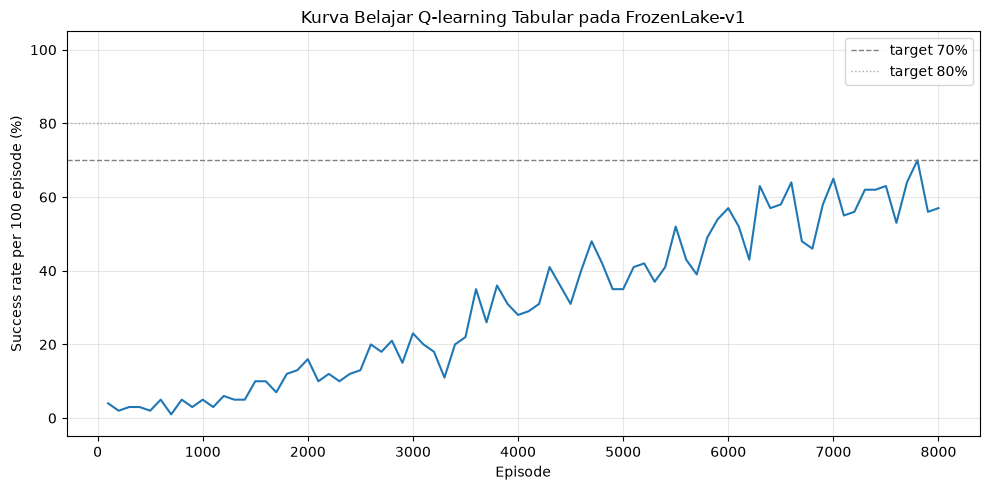

In [7]:
window = 100
success_history_arr = np.array(success_history)

n_windows = len(success_history_arr) // window
success_rate_per_window = success_history_arr[:n_windows * window].reshape(n_windows, window).mean(axis=1) * 100

episodes_axis = np.arange(1, n_windows + 1) * window

plt.figure(figsize=(10, 5))
plt.plot(episodes_axis, success_rate_per_window, color="tab:blue", linewidth=1.5)
plt.axhline(70, color="gray", linestyle="--", linewidth=1, label="target 70%")
plt.axhline(80, color="darkgray", linestyle=":", linewidth=1, label="target 80%")
plt.xlabel("Episode")
plt.ylabel("Success rate per 100 episode (%)")
plt.title("Kurva Belajar Q-learning Tabular pada FrozenLake-v1")
plt.ylim(-5, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Evaluasi Policy Hasil Training (Opsional)

Setelah training, kita evaluasi policy greedy murni (tanpa eksplorasi, `epsilon=0`)
selama beberapa episode untuk mengukur performa akhir yang lebih stabil (tanpa noise
dari sisa eksplorasi acak selama training).


In [8]:
def evaluate_policy(Q, n_eval_episodes=1000):
    successes = 0
    for ep in range(n_eval_episodes):
        state, info = env.reset(seed=10_000 + ep)
        for step in range(max_steps_per_episode):
            action = int(np.argmax(Q[state, :]))   # pure greedy, tanpa eksplorasi
            state, reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                if reward == 1:
                    successes += 1
                break
    return successes / n_eval_episodes * 100

eval_success_rate = evaluate_policy(Q, n_eval_episodes=1000)
print(f"Success rate evaluasi (greedy, 1000 episode): {eval_success_rate:.1f}%")


Success rate evaluasi (greedy, 1000 episode): 72.9%


## 10. Melihat Q-table & Policy yang Dipelajari

Sebagai sanity check, kita tampilkan aksi terbaik (arah panah) untuk setiap
state pada Q-table hasil training. Ini membantu memverifikasi secara visual
apakah policy yang dipelajari masuk akal (mis. mengarah menjauhi hole, menuju goal).


In [9]:
action_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
grid_size = int(np.sqrt(n_states))

policy_grid = []
for s in range(n_states):
    best_a = int(np.argmax(Q[s, :]))
    policy_grid.append(action_arrows[best_a])

policy_grid = np.array(policy_grid).reshape(grid_size, grid_size)

print("Policy (aksi terbaik per state) yang dipelajari:\n")
for row in policy_grid:
    print(" ".join(row))


Policy (aksi terbaik per state) yang dipelajari:

← ↑ ↑ ↑
← ← ← ←
↑ ↓ ← ←
← → ↓ ←


## 11. Penutup: Dari Q-table ke DQN

Notebook ini mendemonstrasikan Q-learning dalam bentuk paling murni: sebuah tabel
yang di-update langsung dengan Bellman equation, tanpa lapisan abstraksi apa pun.

Ketika beralih ke `main.py` pada Stock-MARL, ingat bahwa:

- `model = DQN("MlpPolicy", env, ...)` menggantikan tabel `Q` dengan **neural network**
  yang memetakan state (fitur pasar saham, berdimensi tinggi & kontinu) ke estimasi
  $Q(s,a)$ untuk setiap aksi — karena tabel eksplisit tidak mungkin dibuat untuk
  ruang state sebesar itu.
- `exploration_fraction=0.35` dan `exploration_final_eps=0.1` adalah versi DQN dari
  `epsilon_decay` dan `epsilon_min` pada notebook ini.
- `buffer_size` (*replay buffer*) dan `target_update_interval` (*target network*)
  adalah trik stabilisasi tambahan yang **tidak diperlukan** pada Q-learning tabular
  (karena tabel selalu konsisten dan tidak ada risiko "lupa" akibat gradient update),
  tetapi krusial saat $Q$ diaproksimasi oleh neural network yang bisa menjadi tidak
  stabil jika di-update terlalu agresif dan berkorelasi.

Dengan kata lain: **rumus update yang mendasari** — TD-error $r + \gamma \max_{a'} Q(s',a') - Q(s,a)$ —
sama persis di kedua kasus. Yang berbeda hanyalah *bagaimana* $Q$ direpresentasikan dan
di-update (tabel vs. neural network).
